<a href="https://colab.research.google.com/github/annmaria-roy/ML-LAB/blob/main/fashion_MNIST_classification_using_k_nearest_neighbour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

In [2]:
import seaborn as sns

# Load Fashion-MNIST dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = \
    fashion_mnist.load_data()

# Class names
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print(f"Full Training set shape: {X_train_full.shape}")
print(f"Full Test set shape: {X_test_full.shape}")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full Training set shape: (60000, 28, 28)
Full Test set shape: (10000, 28, 28)


In [5]:
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_full,
    y_train_full,
    test_size=10000,
    stratify=y_train_full,
    random_state=42
)

X_test_sub, _, y_test_sub, _ = train_test_split(
    X_test_full,
    y_test_full,
    test_size=2000,
    stratify=y_test_full,
    random_state=42
)

In [6]:
X_train_flat = X_train_sub.reshape(
    X_train_sub.shape[0], -1
)

X_test_flat = X_test_sub.reshape(
    X_test_sub.shape[0], -1
)

# Normalize pixel values
X_train_norm = X_train_flat / 255.0
X_test_norm = X_test_flat / 255.0

print(
    f"\nSubsampled & Processed Training Shape: "
    f"{X_train_norm.shape}"
)

print(
    f"Subsampled & Processed Testing Shape: "
    f"{X_test_norm.shape}"
)


Subsampled & Processed Training Shape: (50000, 784)
Subsampled & Processed Testing Shape: (8000, 784)


In [4]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import fashion_mnist

# Ensure data variables are loaded and defined
try:
    X_train_norm, y_train_sub, X_test_norm, y_test_sub
except NameError:
    print("Variables not found in memory. Loading and processing Fashion-MNIST...")
    (X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist.load_data()

    X_train_sub, _, y_train_sub, _ = train_test_split(
        X_train_full, y_train_full, test_size=10000, stratify=y_train_full, random_state=42
    )
    X_test_sub, _, y_test_sub, _ = train_test_split(
        X_test_full, y_test_full, test_size=2000, stratify=y_test_full, random_state=42
    )

    X_train_flat = X_train_sub.reshape(X_train_sub.shape[0], -1)
    X_test_flat = X_test_sub.reshape(X_test_sub.shape[0], -1)

    X_train_norm = X_train_flat / 255.0
    X_test_norm = X_test_flat / 255.0

k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = []
inference_times = []

print("Starting KNN Experiments...\n")

for k in k_values:
    print(f"Evaluating K = {k}...")
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2,
        n_jobs=-1
    )
    knn.fit(X_train_norm, y_train_sub)

    # Measure prediction time
    start_time = time.time()
    y_pred = knn.predict(X_test_norm)
    end_time = time.time()

    elapsed_time = end_time - start_time
    acc = accuracy_score(y_test_sub, y_pred)

    accuracies.append(acc)
    inference_times.append(elapsed_time)

    print(
        f"-> Accuracy: {acc:.4f} | "
        f"Inference Time: {elapsed_time:.2f} seconds\n"
    )

Variables not found in memory. Loading and processing Fashion-MNIST...
Starting KNN Experiments...

Evaluating K = 1...
-> Accuracy: 0.8464 | Inference Time: 27.12 seconds

Evaluating K = 3...
-> Accuracy: 0.8502 | Inference Time: 28.21 seconds

Evaluating K = 5...
-> Accuracy: 0.8518 | Inference Time: 27.20 seconds

Evaluating K = 7...
-> Accuracy: 0.8509 | Inference Time: 27.03 seconds

Evaluating K = 9...
-> Accuracy: 0.8471 | Inference Time: 27.45 seconds

Evaluating K = 11...
-> Accuracy: 0.8431 | Inference Time: 27.91 seconds

Evaluating K = 15...
-> Accuracy: 0.8409 | Inference Time: 27.75 seconds



In [8]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Ensure class_names is defined
try:
    class_names
except NameError:
    class_names = [
        'T-shirt/top',
        'Trouser',
        'Pullover',
        'Dress',
        'Coat',
        'Sandal',
        'Shirt',
        'Sneaker',
        'Bag',
        'Ankle boot'
    ]

best_k_idx = np.argmax(accuracies)
best_k = k_values[best_k_idx]

print(f"Optimal configuration found at K = {best_k}")

# Train best KNN model
best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    n_jobs=-1
)

best_knn.fit(X_train_norm, y_train_sub)

y_pred_best = best_knn.predict(X_test_norm)

# Classification report
print("\n### Classification Report ###")

print(
    classification_report(
        y_test_sub,
        y_pred_best,
        target_names=class_names
    )
)

Optimal configuration found at K = 5

### Classification Report ###
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.85      0.81       800
     Trouser       0.98      0.96      0.97       800
    Pullover       0.73      0.82      0.77       800
       Dress       0.89      0.86      0.88       800
        Coat       0.78      0.75      0.77       800
      Sandal       0.99      0.81      0.89       800
       Shirt       0.65      0.59      0.62       800
     Sneaker       0.87      0.96      0.91       800
         Bag       0.97      0.95      0.96       800
  Ankle boot       0.89      0.97      0.93       800

    accuracy                           0.85      8000
   macro avg       0.85      0.85      0.85      8000
weighted avg       0.85      0.85      0.85      8000



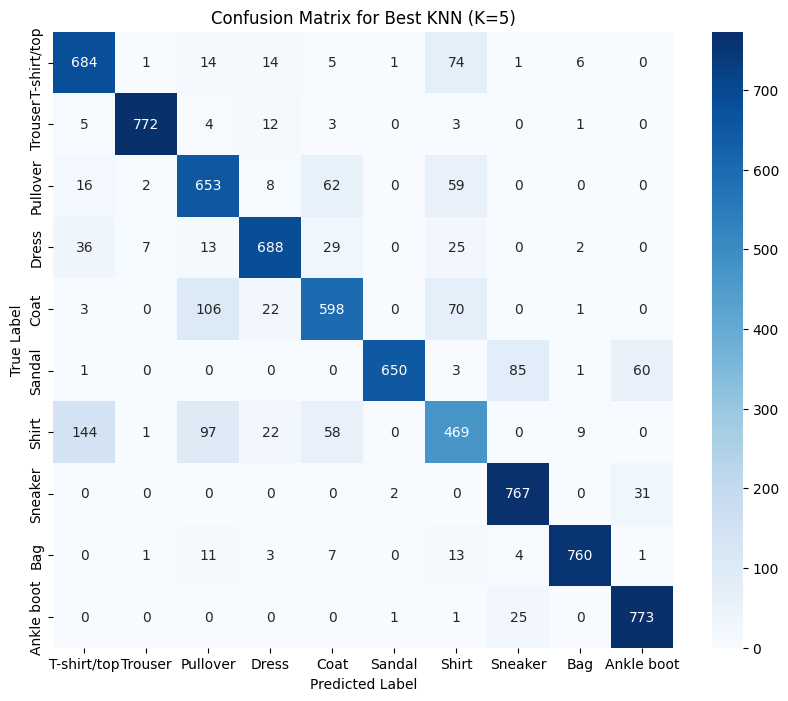

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_sub,
    y_pred_best
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    f'Confusion Matrix for Best KNN (K={best_k})'
)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()